MNIST dataset with torch neural network

In [ ]:
# import all the required dependencies
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define transformation for the images
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,)),  # Normalize with MNIST mean and std
    ]
)

In [ ]:
test_dataset = torchvision.datasets.MNIST(
    root="./data",  # Where to store the dataset
    train=False,  # This is testing dataset
    download=True,  #
    transform=transform,
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Create neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [ ]:
print(f"Is cuda available: {torch.cuda.is_available()}")
# Check if GPU is available
device_name = "cuda:0" if torch.cuda.is_available() else "cpu"

device = torch.device(device_name)

In [ ]:
# Load model
loaded_model = SimpleNN()
loaded_model.load_state_dict(torch.load("mnist_model.pth"))
loaded_model.to(device)
loaded_model.eval()
print("Model Loaded !")

In [62]:
# Function to show predictions
def show_predictions(images, labels, preds):
    length = len(preds);    
    columns = 5   
    
    fig, axes = plt.subplots(13, columns, figsize=(30, 20))
    axes = axes.flatten()

    for i, img in enumerate(images):
        axes[i].imshow(img.cpu().reshape(28, 28), cmap="gray")
        color = "green" if preds[i] == labels[i] else "red"
        axes[i].set_title(f"Pred:{preds[i]}, Actual: {labels[i]}", color=color)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

images.shape torch.Size([64, 1, 28, 28]), length: 64
labels.shape torch.Size([64]), length: 64
outputs.shape torch.Size([64, 10]), length: 64
preds.shape torch.Size([64]), length: 64


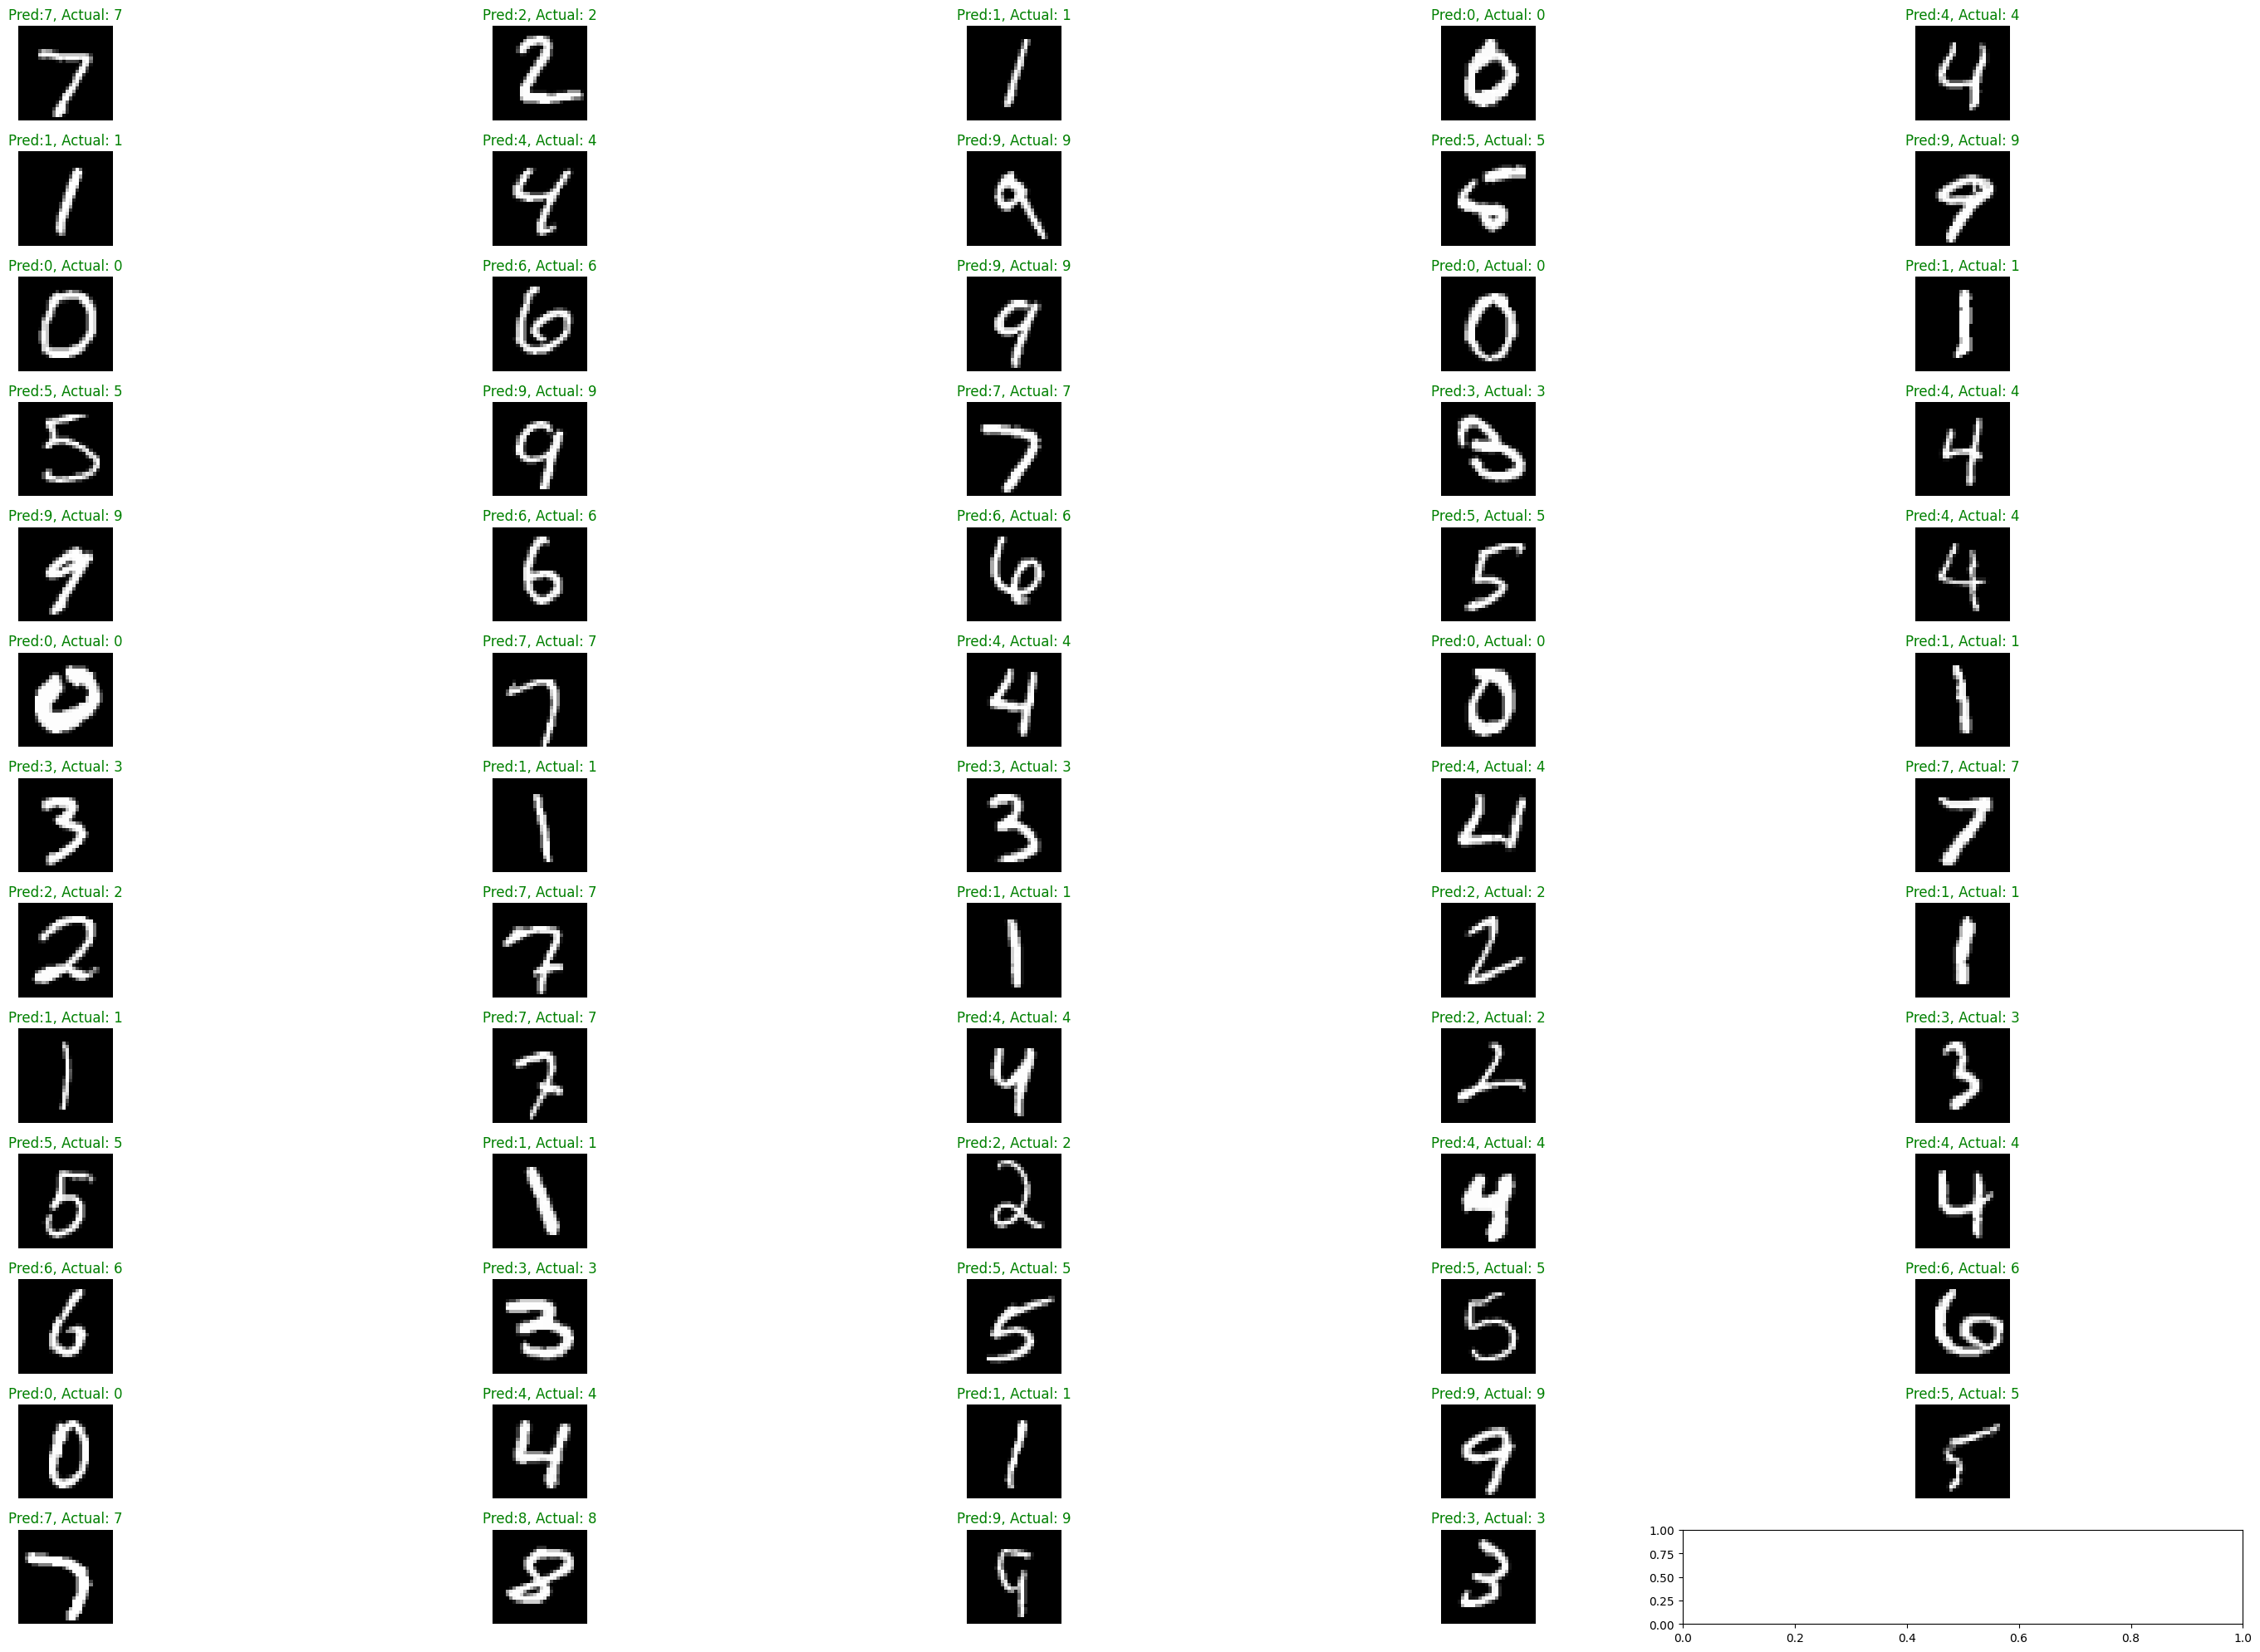

In [63]:
# Get predictions for some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

print(f"images.shape {images.shape}, length: {len(images)}")
print(f"labels.shape {labels.shape}, length: {len(labels)}")


outputs = loaded_model(images)
_, preds = torch.max(outputs, 1)

print(f"outputs.shape {outputs.shape}, length: {len(outputs)}")
print(f"preds.shape {preds.shape}, length: {len(preds)}")

show_predictions(images, labels, preds)